# meshgrid + contour 小演示

这个 notebook 用一个简单二维函数演示 graphene 代码里下面几行在做什么：

```python
uu, vv = np.meshgrid(u, v, indexing="ij")
fig, ax = plt.subplots()
contour = ax.contour(uu, vv, lower_band.reshape(mesh_size, mesh_size), levels=[mu_ev])
segments = [seg for seg in contour.allsegs[0] if len(seg) >= 2]
```

物理上，它是在二维倒空间网格上找满足 `E(k1, k2) = mu` 的等值线。二维体系中，这条等值线就是费米线。

## 1. 构造二维网格

先构造两个一维坐标 `u` 和 `v`，再用 `np.meshgrid` 生成二维网格。

In [2]:
import numpy as np
import matplotlib.pyplot as plt

mesh_size = 50

u = np.arange(mesh_size) / mesh_size
v = np.arange(mesh_size) / mesh_size

uu, vv = np.meshgrid(u, v, indexing="ij")

print("u.shape  =", u.shape)
print("v.shape  =", v.shape)
print("uu.shape =", uu.shape)
print("vv.shape =", vv.shape)

u.shape  = (50,)
v.shape  = (50,)
uu.shape = (50, 50)
vv.shape = (50, 50)


`uu[i, j]` 给出第 `(i, j)` 个网格点的第一个坐标，`vv[i, j]` 给出第二个坐标。因此 `(uu[i, j], vv[i, j])` 就是二维网格上的一个点。

In [3]:
print("前 5 个 u 坐标:")
print(u[:5])

print("\nuu 的左上角 5x5:")
print(uu[:5, :5])

print("\nvv 的左上角 5x5:")
print(vv[:5, :5])

前 5 个 u 坐标:
[0.   0.02 0.04 0.06 0.08]

uu 的左上角 5x5:
[[0.   0.   0.   0.   0.  ]
 [0.02 0.02 0.02 0.02 0.02]
 [0.04 0.04 0.04 0.04 0.04]
 [0.06 0.06 0.06 0.06 0.06]
 [0.08 0.08 0.08 0.08 0.08]]

vv 的左上角 5x5:
[[0.   0.02 0.04 0.06 0.08]
 [0.   0.02 0.04 0.06 0.08]
 [0.   0.02 0.04 0.06 0.08]
 [0.   0.02 0.04 0.06 0.08]
 [0.   0.02 0.04 0.06 0.08]]


## 2. 定义一个简单“能带”

这里不用真实 graphene 能带，而是定义一个简单函数：

$$
E(u,v)=(u-0.5)^2+(v-0.5)^2
$$

它表示每个网格点到中心 `(0.5, 0.5)` 的距离平方。

In [4]:
energy = (uu - 0.5)**2 + (vv - 0.5)**2

print("energy.shape =", energy.shape)
print("energy 的最小值 =", energy.min())
print("energy 的最大值 =", energy.max())

energy.shape = (50, 50)
energy 的最小值 = 0.0
energy 的最大值 = 0.5


## 3. 抽取等值线

设定 `mu = 0.09`，然后找所有满足

$$
E(u,v)=0.09
$$

的点。因为 `E` 是到中心的距离平方，所以这条等值线应该是一条半径 `sqrt(0.09)=0.3` 的圆。

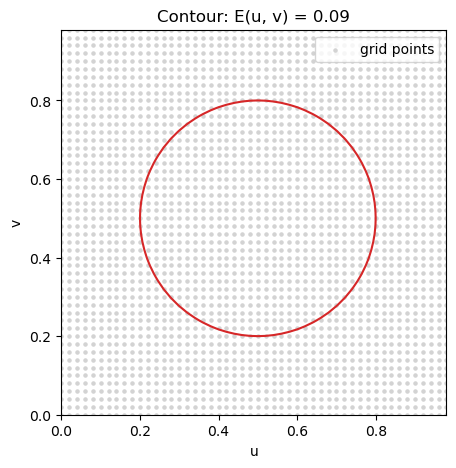

In [5]:
mu = 0.09

fig, ax = plt.subplots(figsize=(5, 5))
contour = ax.contour(uu, vv, energy, levels=[mu], colors="tab:red") #  在二维网格 (uu, vv) 上寻找 energy(u, v) = mu 的等值线，并用红色画出。

ax.scatter(uu, vv, s=5, color="lightgray", label="grid points")
ax.set_aspect("equal")
ax.set_xlabel("u")
ax.set_ylabel("v")
ax.set_title("Contour: E(u, v) = 0.09")
ax.legend()
plt.show()

## 4. 查看 `contour.allsegs`

`contour.allsegs[0]` 存放第一个等值能级的所有等值线片段。这里我们只有一个等值能级 `mu=0.09`，所以取 `[0]`。

In [8]:
segments = [seg for seg in contour.allsegs[0] if len(seg) >= 2]

print("找到的等值线片段数量 =", len(segments))
print("第一条片段的 shape =", segments[0].shape)
print("第一条片段前 5 个点:")
print(segments[0][:5])

找到的等值线片段数量 = 1
第一条片段的 shape = (121, 2)
第一条片段前 5 个点:
[[0.2        0.5       ]
 [0.2        0.5       ]
 [0.20068966 0.48      ]
 [0.20275862 0.46      ]
 [0.2062069  0.44      ]]


`segments[0]` 是一个二维数组，形状为 `(N, 2)`。每一行是等值线上的一个点：

```text
[u坐标, v坐标]
```

在 graphene 代码中，`u, v` 就是约化倒空间坐标，`energy` 换成 `lower_band.reshape(mesh_size, mesh_size)`，`mu` 换成化学势 `mu_ev`。

## 5. 和 graphene 代码对应

demo 中的写法：

```python
contour = ax.contour(uu, vv, energy, levels=[mu])
segments = [seg for seg in contour.allsegs[0] if len(seg) >= 2]
```

graphene 代码中的写法：

```python
contour = ax.contour(uu, vv, lower_band.reshape(mesh_size, mesh_size), levels=[mu_ev])
segments = [seg for seg in contour.allsegs[0] if len(seg) >= 2]
```

区别只是 `energy` 换成了真实的下能带 `E_1(k)`。所以 graphene 代码抽取的是：

```text
E_1(k1, k2) = mu_ev
```

这条等值线就是二维体系的费米线。